In [1]:
import icechunk
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import dask
import pandas as pd

from srm.config import _icechunk_storage_for_path

# A. Define what data arrays exist to traverse

In [2]:
# --- Run parameters --------------------------------------------------------
# This regional South-Africa-box run covers three GCMs, each written to its own icechunk store
# (same bucket/branch, named by GCM the same way srm.cache.ArtifactCache names pipeline output
# stores). Looping over GCMS -- rather than hardcoding one, as this notebook used to -- is what
# lets every leaf be compared against ITS OWN GCM's catalog and lineage instead of silently
# reusing whichever GCM happened to be hardcoded.


VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

In [3]:
GCMS = ["CESM2-WACCM"]

# BRANCH = "full-regional-run-issue-534"
# ROOT_DIR = "s3://carbonplan-scratch/srm/output/qa/"
# STORE_SUBSET_BOUNDS = (-38.0, -19.0, 13.0, 36.0)
# STORE_SUBSET_ID = ArtifactCache._get_subset_id(STORE_SUBSET_BOUNDS)

BRANCH = "v0.13.0"
ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
STORE_SUBSET_ID = "global"

In [4]:
def store_uri(gcm: str, root_dir: str = ROOT_DIR) -> str:
    return f"{root_dir}{gcm}-ERA5-{STORE_SUBSET_ID}.icechunk"

In [5]:
trees: dict[str, xr.DataTree] = {}
open_errors: dict[str, str] = {}

for gcm in GCMS:
    try:
        repo = icechunk.Repository.open(_icechunk_storage_for_path(store_uri(gcm)))
        session = repo.readonly_session(BRANCH) if BRANCH else repo.readonly_session()
        trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks={})
    except Exception as exc:  # noqa: BLE001  # report every failure, do not stop at the first
        open_errors[gcm] = f"{type(exc).__name__}: {exc}"

for gcm, err in open_errors.items():
    print(f"FAILED to open {gcm}: {err}")

# GCMs whose store actually opened. A GCM whose run is still in flight is skipped here rather
# than failing the whole notebook, so this check can be run against a partially-landed run.
OPEN_GCMS = tuple(gcm for gcm in GCMS if gcm in trees)
print(f"opened {len(OPEN_GCMS)}/{len(GCMS)} stores on branch {BRANCH!r}: {', '.join(OPEN_GCMS)}")

trees[OPEN_GCMS[0]]

opened 1/1 stores on branch 'v0.13.0': CESM2-WACCM


<xarray.DataTree>
Group: /
├── Group: /debiased_coarse
│   ├── Group: /debiased_coarse/historical
│   │   ├── Group: /debiased_coarse/historical/dtr
│   │   │   └── Group: /debiased_coarse/historical/dtr/001
│   │   │           Dimensions:  (time: 13514, lat: 192, lon: 288)
│   │   │           Coordinates:
│   │   │             * time     (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
│   │   │             * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │             * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
│   │   │           Data variables:
│   │   │               dtr      (time, lat, lon) float32 3GB dask.array<chunksize=(8000, 8, 16), meta=np.ndarray>
│   │   │           Attributes: (12/19)
│   │   │               Conventions:                                 CF-1.8
│   │   │               institution:                                 CarbonPlan
│   │   │               history:                                     2026-08-07T18:14:50Z: BCSD d...
│   │   │               srm_downscaling:version:                     0.13.0
│   │   │               srm_downscaling:gcm:                         CESM2-WACCM
│   │   │               srm_downscaling:scenario:                    G6-1.5K-END
│   │   │               ...                                          ...
│   │   │               srm_downscaling:train_period:                1978-2014
│   │   │               srm_downscaling:config_hash:                 4ca33f859f26
│   │   │               srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │               srm_downscaling:creation_date:               2026-08-07
│   │   │               srm_downscaling:sai_parent_scenario:         G6-1.5K
│   │   │               srm_downscaling:sai_parent_ensemble_member:  002
│   │   ├── Group: /debiased_coarse/historical/hurs
│   │   │   ├── Group: /debiased_coarse/historical/hurs/r2i1p1f1
│   │   │   │       Dimensions:  (time: 13514, lat: 192, lon: 288)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
│   │   │   │         * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │   │         * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
│   │   │   │       Data variables:
│   │   │   │           hurs     (time, lat, lon) float32 3GB dask.array<chunksize=(8000, 8, 16), meta=np.ndarray>
│   │   │   │       Attributes: (12/19)
│   │   │   │           Conventions:                                 CF-1.8
│   │   │   │           institution:                                 CarbonPlan
│   │   │   │           history:                                     2026-08-07T18:14:47Z: BCSD d...
│   │   │   │           srm_downscaling:version:                     0.13.0
│   │   │   │           srm_downscaling:gcm:                         CESM2-WACCM
│   │   │   │           srm_downscaling:scenario:                    G6-1.5K-END
│   │   │   │           ...                                          ...
│   │   │   │           srm_downscaling:train_period:                1978-2014
│   │   │   │           srm_downscaling:config_hash:                 18e9ccc07b58
│   │   │   │           srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │   │           srm_downscaling:creation_date:               2026-08-07
│   │   │   │           srm_downscaling:sai_parent_scenario:         G6-1.5K
│   │   │   │           srm_downscaling:sai_parent_ensemble_member:  002
│   │   │   └── Group: /debiased_coarse/historical/hurs/r3i1p1f1
│   │   │           Dimensions:  (time: 13514, lat: 192, lon: 288)
│   │   │           Coordinates:
│   │   │             * time     (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
│   │   │             * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │      

In [6]:
gcms, scenarios, variables, ensembles = [], [], [], []

for gcm in OPEN_GCMS:
    tree = trees[gcm]
    for scenario_name, scenario_node in tree.children.items():
        for var_name, var_node in scenario_node.children.items():
            for ens_name, ens_node in var_node.children.items():
                gcms.append(gcm)
                scenarios.append(scenario_name)
                variables.append(var_name)
                ensembles.append(ens_name)

print(f"{len(gcms)} leaves across {len(OPEN_GCMS)} GCMs")

71 leaves across 1 GCMs


In [7]:
keep_idx = [i for i, s in enumerate(scenarios) if s != "debiased_coarse"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

keep_idx = [i for i, v in enumerate(variables) if v != "dtr"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

keep_idx = [i for i, v in enumerate(variables) if v != "hurs"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

In [8]:
tags = []
for i, gcm in enumerate(gcms):
    var = variables[i]
    scenario = scenarios[i]
    ens = ensembles[i]
    tag = f"{gcm}_{var}_{scenario}_{ens}"
    tags.append(tag)

In [9]:
gcms_np = np.array(gcms)
scenarios_np = np.array(scenarios)
variables_np = np.array(variables)
ensembles_np = np.array(ensembles)
tags_np = np.array(tags)

In [10]:
INTERMEDIATE_FLAG_DIR = "s3://carbonplan-scratch/srm/qaqc/flags/" + STORE_SUBSET_ID + "/"

# Get dataset

In [11]:
def get_intermediate_flags(flag_dir: str, tag: str):
    flag_data = xr.open_zarr(flag_dir + tag + ".zarr", consolidated=False)
    return flag_data

In [12]:
def combine_intermediate_flags(
    tag: str,
    flag_dir: str,
    flag_list_time_varying: list,
    flag_list_time_invariant: list,
):
    """
    This calculates two single binary flags from multiple intermediate flags. The intermediate flags

    """

    flags = get_intermediate_flags(flag_dir=flag_dir, tag=tag)

    ind = 0
    for flag_time_varying in flag_list_time_varying:
        if flag_time_varying in flags.variables:
            flag = flags[flag_time_varying]
            if ind == 0:
                overall_flag_time_varying = flag
            else:
                overall_flag_time_varying = overall_flag_time_varying + flag
            ind = ind + 1
    overall_flag_time_varying = overall_flag_time_varying > 0

    ind = 0
    for flag_time_invariant in flag_list_time_invariant:
        if flag_time_invariant in flags.variables:
            flag = flags[flag_time_invariant]
            if ind == 0:
                overall_flag_time_invariant = flag
            else:
                overall_flag_time_invariant = overall_flag_time_invariant + flag
            ind = ind + 1
    overall_flag_time_invariant = overall_flag_time_invariant > 0

    return overall_flag_time_varying, overall_flag_time_invariant

In [13]:
FLAG_LIST_TIME_VARYING = [
    "annual_outlier_flag",
    "rsds_max_exceeded",
    "outside_global_plausible_range",
    "temperature_inconsistency",
]

FLAG_LIST_TIME_INVARIANT = [
    "flipped_signssp245_g6_1p5k",
    "flipped_signhistorical_ssp245",
    "flipped_signhistorical_g6_1p5k",
    "trend_distortion_historical_ssp245",
    "trend_distortion_ssp245_g6_1p5k",
    "trend_distortion_historical_g6_1p5k",
    "flipped_signg6_1p5k_g6_1p5k_end",
    "trend_distortion_g6_1p5k_g6_1p5k_end",
]

In [14]:
tag = "CESM2-WACCM_rsds_ssp245_003"

[overall_flag_time_varying, overall_flag_time_invariant] = combine_intermediate_flags(
    tag=tag,
    flag_dir=INTERMEDIATE_FLAG_DIR,
    flag_list_time_varying=FLAG_LIST_TIME_VARYING,
    flag_list_time_invariant=FLAG_LIST_TIME_INVARIANT,
)

In [15]:
lat = overall_flag_time_invariant.lat
lon = overall_flag_time_invariant.lon

In [16]:
from srm.qa_flags import write_individual_flags, parse_tag

In [18]:
ATTRS_TIME_INVARIANT = {
        "long_name": "Quality flag (time-invariant)",
        "description": "This quality flag flags specific locations where debiasing/downscaling meaningfully changes how scenarios compare to each other in the annual mean, compared to the raw GCM input.",
        "possible_values": "This is a binary flag: 0=no known issue; 1=known issue",
        "short_name": "qa_flag_time_invariant",
    }

ATTRS_TIME_VARYING = {
        "long_name": "Quality flag (time-varying)",
        "description": "This quality flag flags specific days where results are highly sensitive to debiasing/downscaling method choice (e.g. treatment of outliers) and/or where output is physically unrealistic (e.g. tasmax < tas) or unlikely.",
        "possible_values": "This is a binary flag: 0=no known issue; 1=known issue",
    "short_name": "qa_flag_time_varying",
    }

def write_final_qa_flags(
    dataset_path: str,
    flag_data: xr.DataArray,
    flag_name: str,
    attrs: dict,
    write_mode: str = "a",
    time_varying: bool = True,
):
    flag_data = flag_data.rename(flag_name)
    flag_data = flag_data.fillna(0).astype(np.uint8)
    flag_data.attrs = attrs

    if time_varying:
        flag_data = flag_data.chunk({"lat": 100, "lon": 100, "time": 8000})
    else:
        flag_data = flag_data.chunk({"lat": 100, "lon": 100})

    # TO DO: change this to write to icechunk
    flag_data.to_zarr(
        dataset_path,
        mode=write_mode,
        consolidated=False,
        align_chunks=True,
        encoding={flag_name: {"_FillValue": None}},
    )

In [20]:
print(len(tags))
# This loop takes about 15 minutes to run on v0.13.0

for i, tag in enumerate(tags):
    print(tag)
    [gcm, var, scenario, ens] = parse_tag(tag)
    # Get flags
    print("calculating flags")
    [overall_flag_time_varying, overall_flag_time_invariant] = combine_intermediate_flags(
        tag=tag,
        flag_dir=INTERMEDIATE_FLAG_DIR,
        flag_list_time_varying=FLAG_LIST_TIME_VARYING,
        flag_list_time_invariant=FLAG_LIST_TIME_INVARIANT,
    )

    overall_flag_time_varying.compute()
    overall_flag_time_invariant.compute()

    # TO DO: write these flags out to source coop datasets
    # For now, writing these out to the same datasets where the individual flags are
    fpath_out = f"{INTERMEDIATE_FLAG_DIR}/{gcm}_{var}_{scenario}_{ens}.zarr"
    
    print("writing out flags")
    write_final_qa_flags(
        flag_data=overall_flag_time_varying,
        flag_name='flag_time_varying',
        dataset_path=fpath_out,
        attrs=ATTRS_TIME_VARYING,
        write_mode='a',
        time_varying= True,
    )

    write_final_qa_flags(
        flag_data=overall_flag_time_invariant,
        flag_name='flag_time_invariant',
        dataset_path=fpath_out,
        attrs=ATTRS_TIME_INVARIANT,
        write_mode='a',
        time_varying= False,
    )

31
CESM2-WACCM_pr_g6_1p5k_002
calculating flags
writing out flags
CESM2-WACCM_pr_g6_1p5k_003
calculating flags
writing out flags
CESM2-WACCM_rsds_g6_1p5k_002
calculating flags
writing out flags
CESM2-WACCM_rsds_g6_1p5k_003
calculating flags
writing out flags
CESM2-WACCM_tas_g6_1p5k_002
calculating flags
writing out flags
CESM2-WACCM_tas_g6_1p5k_003
calculating flags
writing out flags
CESM2-WACCM_tasmax_g6_1p5k_002
calculating flags
writing out flags
CESM2-WACCM_tasmax_g6_1p5k_003
calculating flags
writing out flags
CESM2-WACCM_tasmin_g6_1p5k_002
calculating flags
writing out flags
CESM2-WACCM_tasmin_g6_1p5k_003
calculating flags
writing out flags
CESM2-WACCM_tasmax_g6_1p5k_end_002
calculating flags
writing out flags
CESM2-WACCM_pr_g6_1p5k_end_002
calculating flags
writing out flags
CESM2-WACCM_rsds_g6_1p5k_end_002
calculating flags
writing out flags
CESM2-WACCM_tas_g6_1p5k_end_002
calculating flags
writing out flags
CESM2-WACCM_tasmin_g6_1p5k_end_002
calculating flags
writing out flags

# Evaluate flag prevalence

In [21]:
from srm import catalog
ocean_mask_geoparquet = catalog.get('ocean-mask')

In [23]:
#Claude-generated patch to get the geoparquet -> gridded mask to work
import rusterize as _rusterize_pkg

_original_rusterize = _rusterize_pkg.rusterize

def _rusterize_patched(*args, **kwargs):
    if kwargs.get("res") is not None and kwargs.get("out_shape") is not None:
        kwargs = dict(kwargs)
        kwargs.pop("res")
    return _original_rusterize(*args, **kwargs)

_rusterize_pkg.rusterize = _rusterize_patched

In [35]:
tag=tags[0]
example_flags = get_intermediate_flags(flag_dir=INTERMEDIATE_FLAG_DIR, tag=tag)
target_grid_da = example_flags['flag_time_invariant']

import xproj  # noqa: registers the .proj accessor
from rasterix.rasterize import geometry_mask

# rusterize requires lat sorted descending; reorder target_grid_da first if needed
template = (
    target_grid_da
    .sortby("lat", ascending=False)
    .proj.assign_crs(spatial_ref="epsg:4326")
)

land_mask = ~geometry_mask(
    template,
    ocean_mask_geoparquet.to_geodataframe()[["geom"]],
    all_touched=True,
    engine="rusterize",
    xdim="lon",
    ydim="lat",
).drop_vars("spatial_ref", errors="ignore")

land_mask.load()

land_mask_u8 = land_mask.astype(np.uint8) # 0/1, still 1 byte
n_land_time_invariant = int(land_mask_u8.sum())  # land pixel count, compute once

# time-varying: land count is per-timestep-constant since land_mask has no time dim
n_land = n_land_time_invariant

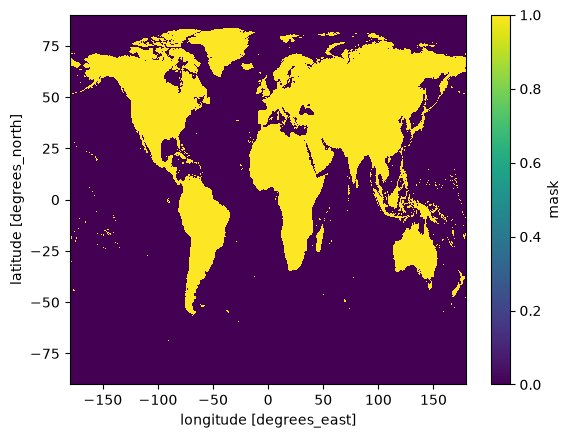

In [36]:
land_mask_u8.plot()

In [37]:
# Note none of these fractions are area-weighted
# This is slow, but it's the land_frac calculations that are slow, I don't know why.
SUMMARY_CSV = "qa_flag_summary.csv"

# land_mask is otherwise recomputed (full coastline rasterization) on every .where() use below
land_mask = land_mask.compute()

summary_rows = []

for i, tag in enumerate(tags):
    flags = get_intermediate_flags(flag_dir=INTERMEDIATE_FLAG_DIR, tag=tag)
    flag_time_varying = flags['flag_time_varying']
    flag_time_invariant = flags['flag_time_invariant']
    flag_time_varying_land = flag_time_varying * land_mask_u8
    flag_time_invariant_land = flag_time_invariant * land_mask_u8
    n_time = flag_time_varying.sizes['time']

    (
        frac_flagged_time_varying,
        frac_space_flagged_time_varying,
        frac_space_flagged_time_invariant,
        land_frac_flagged_time_varying,
        land_frac_space_flagged_time_varying,
        land_frac_space_flagged_time_invariant,
    ) = dask.compute(
        np.nanmean(flag_time_varying),
        np.nanmean(flag_time_varying.sum(dim='time') > 0),
        np.nanmean(flag_time_invariant),
        flag_time_varying_land.sum() / (n_land * n_time),
        (flag_time_varying_land.sum(dim='time') > 0).sum() / n_land,
        flag_time_invariant_land.sum() / n_land,
    )

    # Sanity check: these should each be 0 or 1
    # print(f"  check flag_time_varying max/min:   {np.nanmax(flag_time_varying)} / {np.nanmin(flag_time_varying)}")
    # print(f"  check flag_time_invariant max/min: {np.nanmax(flag_time_invariant)} / {np.nanmin(flag_time_invariant)}")

    print(f"{tag}:")
    print(f"  frac of dataset [time, lat, lon] flagged (time-varying):     {frac_flagged_time_varying:.4g}")
    print(f"  frac of space [lat, lon] with >=1 flagged timestep:          {frac_space_flagged_time_varying:.4g}")
    print(f"  frac of space [lat, lon] with time-invariant flag:           {frac_space_flagged_time_invariant:.4g}")
    print(f"  land frac of dataset [time, lat, lon] flagged (time-varying):{land_frac_flagged_time_varying:.4g}")
    print(f"  land frac of space [lat, lon] with >=1 flagged timestep:     {land_frac_space_flagged_time_varying:.4g}")
    print(f"  land frac of space [lat, lon] with time-invariant flag:      {land_frac_space_flagged_time_invariant:.4g}")

    summary_rows.append({
        "tag": tag,
        "frac_flagged_time_varying": float(frac_flagged_time_varying),
        "frac_space_flagged_time_varying": float(frac_space_flagged_time_varying),
        "frac_space_flagged_time_invariant": float(frac_space_flagged_time_invariant),
        "land_frac_flagged_time_varying": float(land_frac_flagged_time_varying),
        "land_frac_space_flagged_time_varying": float(land_frac_space_flagged_time_varying),
        "land_frac_space_flagged_time_invariant": float(land_frac_space_flagged_time_invariant),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_CSV, index=False)
summary_df

CESM2-WACCM_pr_g6_1p5k_002:
  frac of dataset [time, lat, lon] flagged (time-varying):     8.09e-08
  frac of space [lat, lon] with >=1 flagged timestep:          0.0004931
  frac of space [lat, lon] with time-invariant flag:           0.6642
  land frac of dataset [time, lat, lon] flagged (time-varying):3.002e-07
  land frac of space [lat, lon] with >=1 flagged timestep:     0.001894
  land frac of space [lat, lon] with time-invariant flag:      0.7589
CESM2-WACCM_pr_g6_1p5k_003:
  frac of dataset [time, lat, lon] flagged (time-varying):     7.768e-08
  frac of space [lat, lon] with >=1 flagged timestep:          0.0004787
  frac of space [lat, lon] with time-invariant flag:           0.6642
  land frac of dataset [time, lat, lon] flagged (time-varying):2.887e-07
  land frac of space [lat, lon] with >=1 flagged timestep:     0.001815
  land frac of space [lat, lon] with time-invariant flag:      0.7589
CESM2-WACCM_rsds_g6_1p5k_002:
  frac of dataset [time, lat, lon] flagged (time-vary

,tag,frac_flagged_time_varying,frac_space_flagged_time_varying,frac_space_flagged_time_invariant,land_frac_flagged_time_varying,land_frac_space_flagged_time_varying,land_frac_space_flagged_time_invariant
0,CESM2-WACCM_pr_g6_1p5k_002,8.090130e-08,0.000493,0.664191,3.002127e-07,0.001894,0.758948
1,CESM2-WACCM_pr_g6_1p5k_003,7.768423e-08,0.000479,0.664191,2.887370e-07,0.001815,0.758948
2,CESM2-WACCM_rsds_g6_1p5k_002,2.351584e-02,0.350506,0.645960,8.525481e-03,0.232803,0.701722
3,CESM2-WACCM_rsds_g6_1p5k_003,2.353456e-02,0.353095,0.645960,8.538522e-03,0.236205,0.701722
4,CESM2-WACCM_tas_g6_1p5k_002,8.019258e-02,0.970797,0.258425,2.643127e-02,0.886984,0.306261
5,CESM2-WACCM_tas_g6_1p5k_003,8.178404e-02,0.972532,0.258425,2.561686e-02,0.893421,0.306261
6,CESM2-WACCM_tasmax_g6_1p5k_002,3.983610e-02,0.867840,0.303051,2.018254e-02,0.791153,0.381617
7,CESM2-WACCM_tasmax_g6_1p5k_003,2.984663e-02,0.856465,0.303051,1.591354e-02,0.761999,0.381617
8,CESM2-WACCM_tasmin_g6_1p5k_002,4.035693e-02,0.943152,0.335950,6.249800e-03,0.780932,0.363982
9,CESM2-WACCM_tasmin_g6_1p5k_003,5.193795e-02,0.952370,0.335950,9.704653e-03,0.815131,0.363982
